#📌 Extracão

In [1]:
# 1. Importação das bibliotecas
import pandas as pd
import json

# 2. Definição do nome do arquivo (deve estar na raiz do Colab)
caminho_arquivo = 'TelecomX_Data.json'

# 3. Leitura dos dados brutos do JSON
with open(caminho_arquivo, 'r', encoding='utf-8') as arquivo:
    dados_brutos = json.load(arquivo)

# 4. Conversão para DataFrame e achatamento (flatten) das colunas aninhadas
df_telecom = pd.json_normalize(dados_brutos)

# 5. Configuração para exibir todas as colunas sem cortes visuais
pd.set_option('display.max_columns', None)

In [2]:
# Visualizando as 5 primeiras linhas do DataFrame
display(df_telecom.head())

print("\n" + "="*80 + "\n")

# Analisando as informações gerais, quantidade de linhas, colunas e tipos de dados
df_telecom.info()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,internet.OnlineSecurity,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   obj

#🔧 Transformação

In [3]:
# 1. Removendo os prefixos das colunas para facilitar a chamada das variáveis
df_telecom.columns = [col.split('.')[-1] for col in df_telecom.columns]

# 2. Verificando os novos nomes das colunas
print("Colunas padronizadas:")
print(df_telecom.columns.tolist())

Colunas padronizadas:
['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Monthly', 'Total']


In [4]:
# Verificando o tipo de dado de cada coluna
display(df_telecom.dtypes)

customerID           object
Churn                object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
Monthly             float64
Total                object
dtype: object

In [5]:
import numpy as np

# 1. Convertendo a coluna 'Total' de string para numérico (float)
# O parâmetro errors='coerce' transforma espaços em branco ou erros em NaN (nulo)
df_telecom['Total'] = pd.to_numeric(df_telecom['Total'], errors='coerce')

# 2. Verificando se foram gerados valores nulos após a conversão
nulos_total = df_telecom['Total'].isnull().sum()
print(f"Valores nulos na coluna 'Total' após conversão: {nulos_total}")

# 3. Analisando as linhas com valores nulos (geralmente clientes com tenure = 0)
display(df_telecom[df_telecom['Total'].isnull()])

# 4. Tratamento: Como são clientes novos (tenure = 0), podemos preencher o 'Total' vazio com 0, 
# ou preencher com o valor do primeiro mês ('Monthly'). Aqui, preencheremos com 0.
df_telecom['Total'] = df_telecom['Total'].fillna(0)

# 5. Validação final dos tipos de dados e nulos
print("\n" + "="*50 + "\n")
print("Informações atualizadas após tratamento:")
df_telecom.info()

Valores nulos na coluna 'Total' após conversão: 11


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,NaN
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN




Informações atualizadas após tratamento:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16 

### 📌 Conclusão da Transformação
Após a limpeza, o dataset está pronto. Com base no dicionário, as colunas mais relevantes para iniciar a análise de **Churn** (evasão) são:

* **Variável Alvo (Target):** `Churn` (Indica se o cliente saiu ou não).
* **Variáveis de Serviço:** `Contract` (Tipo de contrato), `InternetService`, `OnlineSecurity`, `TechSupport` (podem indicar se a qualidade/tipo do serviço retém o cliente).
* **Variáveis Financeiras:** `Monthly` (Mensalidade) e `Total` (Gasto total) - valores altos podem motivar cancelamentos.
* **Variável de Engajamento:** `tenure` (Meses de contrato - quanto tempo o cliente permanece na empresa).

### 🔍 Verificação de Problemas nos Dados
Nesta etapa, vamos garantir a qualidade da nossa base de dados:
1. Identificando e removendo linhas duplicadas.
2. Tratando valores vazios e inconsistências nas categorias, com atenção especial à nossa variável alvo (`Churn`).

In [6]:
# 1. Verificando a existência de linhas completamente duplicadas
total_duplicadas = df_telecom.duplicated().sum()
print(f"Total de linhas duplicadas encontradas: {total_duplicadas}")

# 2. Remoção das duplicadas (caso existam)
if total_duplicadas > 0:
    df_telecom = df_telecom.drop_duplicates()
    print("Linhas duplicadas removidas com sucesso.")

Total de linhas duplicadas encontradas: 0


In [7]:
# 1. Verificando as categorias dentro da coluna alvo 'Churn'
print("Valores únicos e suas quantidades na coluna 'Churn' (antes da limpeza):")
print(df_telecom['Churn'].value_counts(dropna=False))

# 2. Nota-se que existem valores vazios (""). Como 'Churn' é nossa variável alvo, 
# não podemos estimá-la. A melhor prática é remover essas linhas.
df_telecom = df_telecom[df_telecom['Churn'] != ""]

# 3. Validação após a remoção
print("\nValores na coluna 'Churn' após limpeza:")
print(df_telecom['Churn'].value_counts())

Valores únicos e suas quantidades na coluna 'Churn' (antes da limpeza):
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

Valores na coluna 'Churn' após limpeza:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [8]:
# 1. Lista de colunas com a categoria "No internet service"
colunas_internet = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# 2. Substituindo "No internet service" por "No"
for col in colunas_internet:
    df_telecom[col] = df_telecom[col].replace('No internet service', 'No')

# 3. Substituindo "No phone service" por "No" na coluna MultipleLines
df_telecom['MultipleLines'] = df_telecom['MultipleLines'].replace('No phone service', 'No')

# 4. Verificando o resultado em uma das colunas afetadas
print("Categorias da coluna 'TechSupport' após padronização:")
print(df_telecom['TechSupport'].value_counts())

Categorias da coluna 'TechSupport' após padronização:
TechSupport
No     4999
Yes    2044
Name: count, dtype: int64


### ✅ Resumo da Limpeza de Dados:
* Variáveis numéricas convertidas corretamente (`Total`).
* Linhas com a variável alvo (`Churn`) vazia foram descartadas.
* Categorias redundantes em serviços de internet e telefone foram unificadas para `"No"`.
* O dataset agora está consistente e pronto para a **Análise Exploratória**.

### 🔤 Padronização e Manipulação de Textos (Strings)
Para evitar que categorias idênticas sejam tratadas como diferentes por causa de letras maiúsculas/minúsculas ou espaços em branco invisíveis, aplicaremos funções de string do Pandas (`lower`, `strip`, `replace`, `contains`).

**Ações:**
1. Converter todas as categorias para letras minúsculas.
2. Remover espaços em branco no início ou no final das palavras.
3. Simplificar as categorias da coluna `PaymentMethod`.
4. Criar uma variável indicadora usando `contains`.

In [9]:
# 1. Identificando todas as colunas que contêm texto (tipo 'object')
colunas_texto = df_telecom.select_dtypes(include=['object']).columns

# 2. Iterando sobre essas colunas para aplicar .str.lower() e .str.strip()
# Isso garante que "Yes", "yes " e "YES" se tornem todos "yes"
for coluna in colunas_texto:
    df_telecom[coluna] = df_telecom[coluna].str.lower().str.strip()

print("✅ Todos os textos foram convertidos para minúsculas e tiveram espaços extras removidos.")

✅ Todos os textos foram convertidos para minúsculas e tiveram espaços extras removidos.


In [11]:
# 1. Uso do replace: Simplificando a coluna PaymentMethod
# O 'r' antes da string resolve o SyntaxWarning
df_telecom['PaymentMethod'] = df_telecom['PaymentMethod'].str.replace(r' \(automatic\)', '', regex=True)

# 2. Uso do contains: Criando uma nova coluna (Feature Engineering básica)
# Vamos sinalizar contratos de longo prazo (que contêm a palavra 'year')
df_telecom['Contrato_Longo'] = df_telecom['Contract'].str.contains('year')

# Verificando as transformações aplicadas
display(df_telecom[['customerID', 'PaymentMethod', 'Contract', 'Contrato_Longo']].head())

,customerID,PaymentMethod,Contract,Contrato_Longo
0,0002-orfbo,mailed check,one year,True
1,0003-mknfe,mailed check,month-to-month,False
2,0004-tlhlj,electronic check,month-to-month,False
3,0011-igkff,electronic check,month-to-month,False
4,0013-exchz,mailed check,month-to-month,False


In [12]:
# Removendo a coluna de demonstração do ID, pois não tem utilidade analítica
df_telecom = df_telecom.drop(columns=['ID_Comeca_000'])

# Resetando o índice do DataFrame após todas as limpezas e remoções de linhas
df_telecom.reset_index(drop=True, inplace=True)

# Visão geral final do dataset transformado
print(f"Tamanho final do dataset: {df_telecom.shape[0]} linhas e {df_telecom.shape[1]} colunas.\n")
display(df_telecom.head())

Tamanho final do dataset: 7043 linhas e 22 colunas.



,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total,Contrato_Longo
0,0002-orfbo,no,female,0,yes,yes,9,yes,no,dsl,no,yes,no,yes,yes,no,one year,yes,mailed check,65.6,593.30,True
1,0003-mknfe,no,male,0,no,no,9,yes,yes,dsl,no,no,no,no,no,yes,month-to-month,no,mailed check,59.9,542.40,False
2,0004-tlhlj,yes,male,0,no,no,4,yes,no,fiber optic,no,no,yes,no,no,no,month-to-month,yes,electronic check,73.9,280.85,False
3,0011-igkff,yes,male,1,yes,no,13,yes,no,fiber optic,no,yes,yes,no,yes,yes,month-to-month,yes,electronic check,98.0,1237.85,False
4,0013-exchz,yes,female,1,yes,no,3,yes,no,fiber optic,no,no,no,yes,yes,no,month-to-month,yes,mailed check,83.9,267.40,False


#📊 Carga e análise

# 📊 Carga e Análise Exploratória (EDA)

## 1. Análise Descritiva
O primeiro passo da nossa análise é compreender a distribuição dos dados. Utilizaremos medidas de tendência central (média, mediana) e dispersão (desvio padrão) para as variáveis numéricas, e analisaremos as frequências das variáveis categóricas, com foco especial na nossa variável alvo (`Churn`).

In [13]:
# 1. Gerando o resumo estatístico para as colunas numéricas
# O .round(2) facilita a leitura ao limitar para duas casas decimais
estatisticas_num = df_telecom.describe().round(2)

print("Estatísticas Descritivas (Variáveis Numéricas):")
display(estatisticas_num)

Estatísticas Descritivas (Variáveis Numéricas):


,SeniorCitizen,tenure,Monthly,Total
count,7043.00,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76,2279.73
std,0.37,24.56,30.09,2266.79
min,0.00,0.00,18.25,0.00
25%,0.00,9.00,35.50,398.55
50%,0.00,29.00,70.35,1394.55
75%,0.00,55.00,89.85,3786.60
max,1.00,72.00,118.75,8684.80


### 💡 Como ler o resultado acima:
* **count:** Quantidade de registros válidos (sempre bom checar se batem com o total de linhas).
* **mean (Média):** O valor médio gasto ou o tempo médio de permanência dos clientes.
* **std (Desvio Padrão):** O quanto os dados variam em relação à média. Um `std` alto no `Total` indica grande disparidade de gastos entre os clientes.
* **50% (Mediana):** O valor exato do meio do dataset. Se a **média** for muito maior que a **mediana**, significa que existem clientes com gastos extremos puxando a média para cima.

In [14]:
# 1. Gerando resumo estatístico para variáveis categóricas (tipo 'object' e 'bool')
# Mostra a quantidade de categorias únicas (unique), o valor mais comum (top) e sua frequência (freq)
estatisticas_cat = df_telecom.describe(include=['object', 'bool'])

print("Estatísticas Descritivas (Variáveis Categóricas):")
display(estatisticas_cat)

print("\n" + "="*60 + "\n")

# 2. Calculando a porcentagem de Churn (Variável Alvo)
# O normalize=True retorna a proporção em vez da contagem absoluta. Multiplicamos por 100 para ter a %
taxa_churn = df_telecom['Churn'].value_counts(normalize=True) * 100

print("🚨 Taxa de Evasão de Clientes (Churn):")
print(taxa_churn.round(2).astype(str) + ' %')

Estatísticas Descritivas (Variáveis Categóricas):


,customerID,Churn,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Contrato_Longo
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,2,2,3,2,2,2,2,2,2,3,2,4,2
top,0002-orfbo,no,male,no,no,yes,no,fiber optic,no,no,no,no,no,no,month-to-month,yes,electronic check,False
freq,1,5174,3555,3641,4933,6361,4072,3096,5024,4614,4621,4999,4336,4311,3875,4171,2365,3875




🚨 Taxa de Evasão de Clientes (Churn):
Churn
no     73.46 %
yes    26.54 %
Name: proportion, dtype: object


## 2. Visualização da Variável Alvo (Churn)
Nesta etapa, vamos visualizar graficamente como a evasão está distribuída. Isso nos ajudará a entender o desbalanceamento dos dados, ou seja, a proporção entre os clientes que permaneceram na empresa e os que cancelaram o serviço.

C:\Users\marco\AppData\Local\Temp\ipykernel_10688\920557191.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_telecom, x='Churn', palette=cores, order=['no', 'yes'])


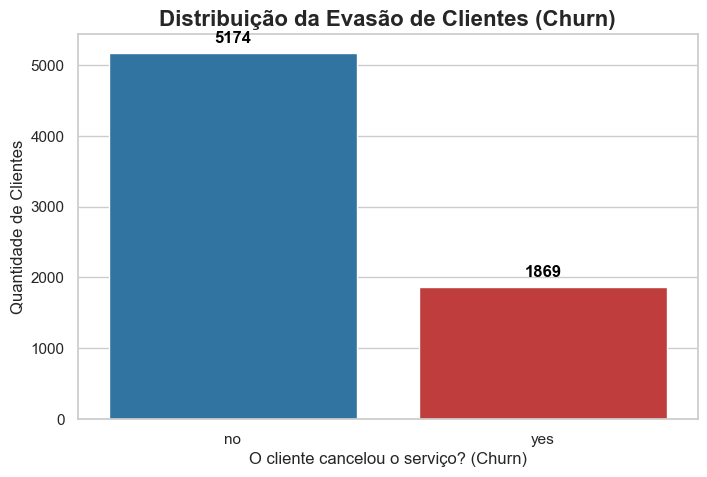

In [15]:
# 1. Importando bibliotecas de visualização
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Configurando o estilo visual dos gráficos
sns.set_theme(style="whitegrid")

# 3. Criando a figura com um tamanho adequado
plt.figure(figsize=(8, 5))

# 4. Criando o gráfico de barras (countplot)
# Utilizamos cores distintas: azul para 'não' (permaneceu) e vermelho para 'sim' (evadiu)
cores = {'no': '#1f77b4', 'yes': '#d62728'}
ax = sns.countplot(data=df_telecom, x='Churn', palette=cores, order=['no', 'yes'])

# 5. Personalizando títulos e rótulos
plt.title('Distribuição da Evasão de Clientes (Churn)', fontsize=16, fontweight='bold')
plt.xlabel('O cliente cancelou o serviço? (Churn)', fontsize=12)
plt.ylabel('Quantidade de Clientes', fontsize=12)

# 6. Adicionando os rótulos de dados (valores) no topo de cada barra
for p in ax.patches:
    altura = p.get_height()
    ax.annotate(f'{int(altura)}', 
                (p.get_x() + p.get_width() / 2., altura), 
                ha='center', va='bottom', 
                fontsize=12, fontweight='bold', color='black', 
                xytext=(0, 5), textcoords='offset points')

# 7. Exibindo o gráfico
plt.show()

### 💡 Insight sobre a Variável Alvo:
* O gráfico nos mostra claramente que a base de dados é **desbalanceada**. 
* A maioria dos clientes na base atual **não** cancelou o serviço (`no`).
* Apesar de menor, o grupo que cancelou (`yes`) representa uma fatia significativa (aproximadamente 26% da base, conforme calculado anteriormente). Modelos preditivos futuros precisarão levar esse desbalanceamento em consideração (usando técnicas como SMOTE ou ajuste de pesos) para não se tornarem tendenciosos.

## 3. Análise de Churn por Variáveis Categóricas
Nesta etapa, vamos cruzar a nossa variável alvo (`Churn`) com características dos clientes, como gênero, tipo de contrato, método de pagamento e serviço de internet. O objetivo é identificar perfis que apresentam maior risco de cancelamento.

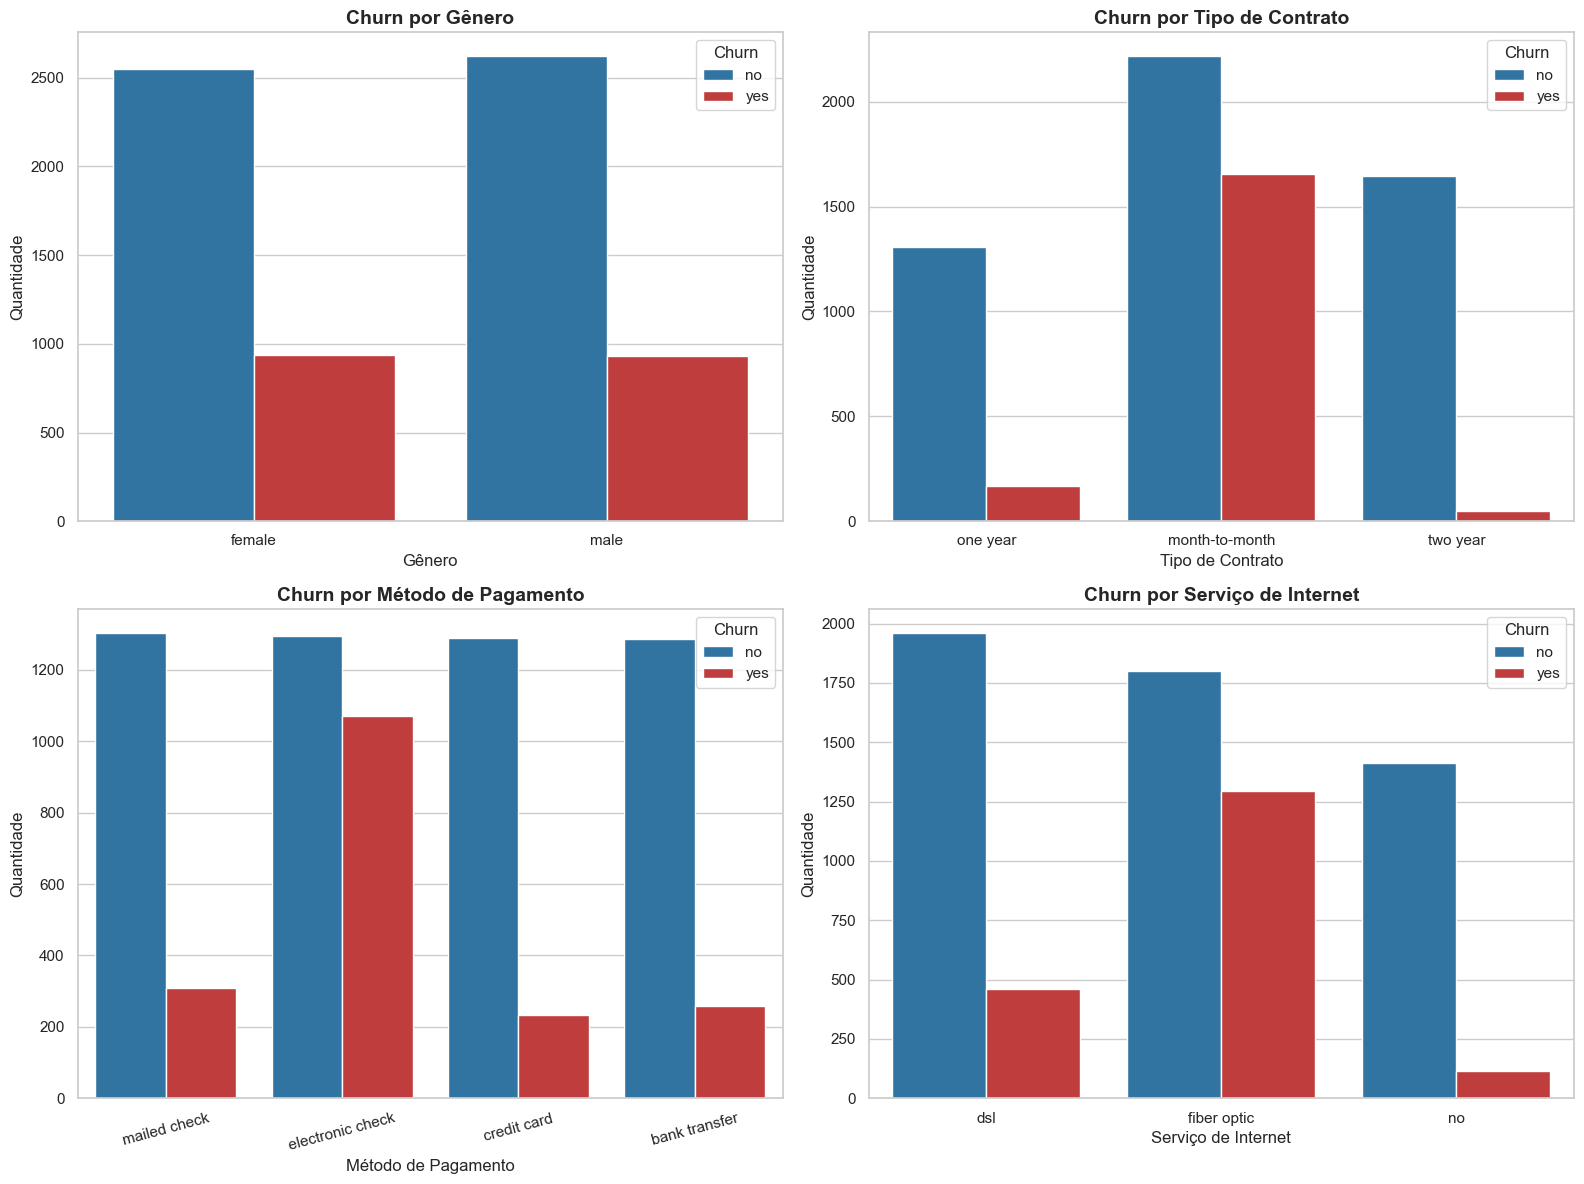

In [16]:
# 1. Configurando o tamanho da figura e criando uma grade 2x2 para os gráficos
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
sns.set_theme(style="whitegrid")

# Definindo a paleta de cores padrão
cores = {'no': '#1f77b4', 'yes': '#d62728'}

# Gráfico 1: Churn por Gênero
sns.countplot(data=df_telecom, x='gender', hue='Churn', palette=cores, ax=axes[0, 0])
axes[0, 0].set_title('Churn por Gênero', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Gênero')
axes[0, 0].set_ylabel('Quantidade')

# Gráfico 2: Churn por Tipo de Contrato
sns.countplot(data=df_telecom, x='Contract', hue='Churn', palette=cores, ax=axes[0, 1])
axes[0, 1].set_title('Churn por Tipo de Contrato', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Tipo de Contrato')
axes[0, 1].set_ylabel('Quantidade')

# Gráfico 3: Churn por Método de Pagamento
sns.countplot(data=df_telecom, x='PaymentMethod', hue='Churn', palette=cores, ax=axes[1, 0])
axes[1, 0].set_title('Churn por Método de Pagamento', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Método de Pagamento')
axes[1, 0].set_ylabel('Quantidade')
axes[1, 0].tick_params(axis='x', rotation=15) # Rotaciona os textos do eixo X para não sobrepor

# Gráfico 4: Churn por Serviço de Internet
sns.countplot(data=df_telecom, x='InternetService', hue='Churn', palette=cores, ax=axes[1, 1])
axes[1, 1].set_title('Churn por Serviço de Internet', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Serviço de Internet')
axes[1, 1].set_ylabel('Quantidade')

# Ajustando o layout para que os gráficos não fiquem colados uns nos outros
plt.tight_layout()
plt.show()

### 💡 Insights da Análise Categórica:
Após observar os gráficos, podemos destacar padrões claros de comportamento:
1. **Gênero:** A proporção de evasão é praticamente idêntica entre homens e mulheres. O gênero **não** é um fator determinante para o Churn.
2. **Contrato (Contract):** Clientes com contratos mensais (`month-to-month`) têm uma taxa de cancelamento altíssima se comparados aos contratos anuais ou bianuais. Isso indica que prender o cliente a longo prazo (oferecendo descontos, por exemplo) é uma ótima estratégia de retenção.
3. **Pagamento (Payment Method):** Clientes que pagam via cheque eletrônico (`electronic check`) cancelam muito mais do que os demais. Pode haver um problema no sistema de cobrança, falta de facilidade no pagamento ou é o método preferido de clientes temporários.
4. **Internet:** Assinantes do serviço de Fibra Óptica (`fiber optic`) apresentam mais Churn do que os de DSL. Isso é um alerta grave para a equipe técnica da Telecom X: a fibra óptica pode estar apresentando instabilidade, preço alto ou suporte ruim frente aos concorrentes.

## 4. Análise de Churn por Variáveis Numéricas
Agora, vamos investigar como o tempo de permanência (`tenure`), o valor da mensalidade (`Monthly`) e o gasto total (`Total`) influenciam a taxa de evasão. Utilizaremos **Boxplots** para comparar a distribuição desses valores entre os clientes que ficaram e os que cancelaram.

C:\Users\marco\AppData\Local\Temp\ipykernel_10688\3958061861.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_telecom, x='Churn', y='tenure', palette=cores, ax=axes[0])
C:\Users\marco\AppData\Local\Temp\ipykernel_10688\3958061861.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_telecom, x='Churn', y='Monthly', palette=cores, ax=axes[1])
C:\Users\marco\AppData\Local\Temp\ipykernel_10688\3958061861.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_telecom, x='Churn', y='Total', palette=cores, ax=axes[2])


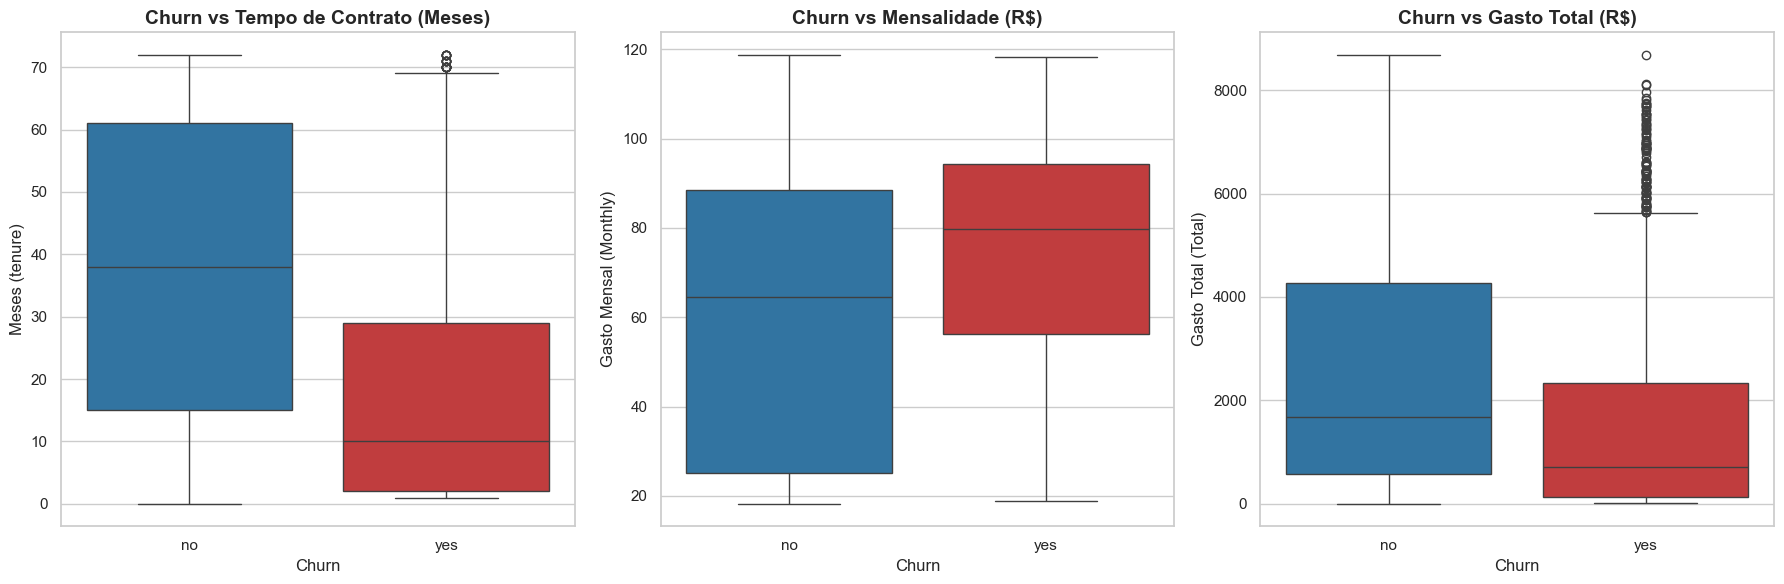

In [17]:
# 1. Configurando a figura para exibir 3 gráficos lado a lado (1 linha, 3 colunas)
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))
sns.set_theme(style="whitegrid")

cores = {'no': '#1f77b4', 'yes': '#d62728'}

# Gráfico 1: Churn vs Tempo de Contrato (tenure)
sns.boxplot(data=df_telecom, x='Churn', y='tenure', palette=cores, ax=axes[0])
axes[0].set_title('Churn vs Tempo de Contrato (Meses)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Meses (tenure)')

# Gráfico 2: Churn vs Gasto Mensal (Monthly)
sns.boxplot(data=df_telecom, x='Churn', y='Monthly', palette=cores, ax=axes[1])
axes[1].set_title('Churn vs Mensalidade (R$)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Gasto Mensal (Monthly)')

# Gráfico 3: Churn vs Gasto Total (Total)
sns.boxplot(data=df_telecom, x='Churn', y='Total', palette=cores, ax=axes[2])
axes[2].set_title('Churn vs Gasto Total (R$)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Churn')
axes[2].set_ylabel('Gasto Total (Total)')

# Ajustando o layout
plt.tight_layout()
plt.show()

### 💡 Insights da Análise Numérica:
Ao analisar os Boxplots, extraímos conclusões valiosas sobre o comportamento financeiro e de fidelidade:
1. **Tempo de Contrato (tenure):** A caixa vermelha (clientes que cancelaram) está concentrada na parte inferior do gráfico, indicando que **a maior parte das evasões ocorre nos primeiros meses** de assinatura. Clientes com muito tempo de casa tendem a ser fiéis.
2. **Mensalidade (Monthly):** Clientes que cancelaram possuem uma mediana de gastos mensais significativamente **maior** do que os que permaneceram. Isso sugere que serviços mais caros (como a Fibra Óptica que vimos no gráfico anterior) estão pesando no bolso do cliente e motivando o cancelamento.
3. **Gasto Total (Total):** O gasto total dos que cancelaram é menor. Isso é uma consequência direta do tempo de contrato: como eles cancelam muito cedo (baixo `tenure`), não acumulam um valor total alto ao longo dos anos, mesmo tendo uma mensalidade mais alta.

#📄Relatorio Final

# 📑 Relatório Final: Análise de Evasão de Clientes (Churn) - Telecom X


## 1. Introdução
O presente relatório documenta o processo de análise de dados focado no problema de evasão de clientes (Churn) enfrentado pela **Telecom X**. O objetivo principal deste projeto foi extrair, tratar e explorar os dados dos clientes para identificar padrões comportamentais e características de serviço que influenciam diretamente a decisão de cancelamento. Compreender esses fatores é o primeiro passo para que a equipe de Data Science desenvolva modelos preditivos eficazes e para que a área de negócios aplique estratégias de retenção.

## 2. Limpeza e Tratamento de Dados
Para garantir a confiabilidade da análise, os dados brutos passaram por um rigoroso processo de ETL (Extração, Transformação e Carga):
* **Extração:** Os dados foram consumidos a partir de um arquivo JSON (simulando uma API) e convertidos para uma estrutura tabular utilizando o método de achatamento (`json_normalize`) do Pandas.
* **Transformação de Tipos:** A variável financeira `Total` foi corrigida de texto (string) para numérico (float). Valores vazios oriundos de clientes recém-adquiridos foram preenchidos com zero.
* **Limpeza:** Linhas onde a variável alvo (`Churn`) estava ausente foram removidas, pois inviabilizariam a modelagem.
* **Padronização:** Strings foram convertidas para minúsculas, espaços extras foram removidos e categorias redundantes (como "No internet service") foram unificadas para "no", garantindo consistência na análise.

## 3. Análise Exploratória de Dados (EDA)
A exploração visual e estatística revelou o comportamento da base de clientes frente à evasão:
* **Desbalanceamento:** Cerca de 26% da base atual cancelou o serviço, indicando um problema significativo, mas configurando uma base desbalanceada para futuros modelos de Machine Learning.
* **Variáveis Categóricas:** A análise por subgráficos demonstrou que o gênero não afeta o Churn. No entanto, o tipo de contrato (mensal), o método de pagamento (cheque eletrônico) e o tipo de internet (fibra óptica) apresentaram altas taxas de cancelamento.
* **Variáveis Numéricas:** Os Boxplots evidenciaram que a evasão se concentra fortemente nos primeiros meses de assinatura (baixo `tenure`) e está associada a clientes que possuem mensalidades mais altas (`Monthly` charges).



## 4. Conclusões e Insights
A partir da EDA, os principais achados que respondem ao problema de negócios são:
1. **Risco Inicial:** O cliente da Telecom X tem maior probabilidade de cancelar o serviço logo no início da sua jornada. Se ele ultrapassa os primeiros meses, a tendência é que se torne um cliente fiel.
2. **O Problema do Curto Prazo:** Contratos no modelo "mês a mês" não geram barreira de saída, facilitando a evasão ao menor sinal de insatisfação.
3. **Alerta na Fibra Óptica:** Clientes com internet de Fibra Óptica estão cancelando mais do que os de tecnologia mais antiga (DSL). Considerando que a fibra costuma ter uma mensalidade maior, o cliente pode não estar enxergando valor ou o serviço pode estar apresentando falhas técnicas.

## 5. Recomendações Estratégicas
Com base nos dados analisados, sugerem-se as seguintes ações para a Telecom X reduzir seu índice de Churn:
* **Incentivo a Contratos Longos:** Criar campanhas agressivas de desconto ou upgrade de serviços para clientes que aceitarem migrar do plano "mês a mês" para contratos de 1 ou 2 anos.
* **Programa de Onboarding e Retenção Inicial:** Como o Churn é alto nos primeiros meses, implementar um contato proativo (Customer Success) nas primeiras semanas de assinatura para garantir que o cliente está satisfeito e sabe usar os serviços contratados.
* **Auditoria no Serviço de Fibra Óptica:** O time técnico deve investigar imediatamente a estabilidade e a velocidade real entregue nos planos de fibra óptica, enquanto o time de produto deve reavaliar se o preço cobrado está competitivo frente ao mercado.
* **Facilitação de Pagamentos:** Investigar os motivos pelos quais o "electronic check" gera tanta evasão e incentivar a migração para métodos de pagamento automáticos (como cartão de crédito ou débito em conta), que apresentam taxas de retenção melhores.

---
**Autora:** Nicole Marcondes

*Análise desenvolvida em Python (Pandas, Matplotlib, Seaborn).*